# Prepare the Cat vs Dog Dataset

This notebook prepares the PetImages dataset for model training. It covers reproducibility, corrupted-image cleanup, dataset loading, splitting, preprocessing, and visualization of augmented samples.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

cwd = Path.cwd().resolve()
project_root_candidates = [cwd, cwd.parent]
project_root = next((candidate for candidate in project_root_candidates if (candidate / "src").exists() and (candidate / "PetImages").exists()), cwd)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_utils import DATASET_ROOT, build_datasets, remove_corrupted_images, set_seed

# Use a consistent seed for reproducibility across Python, NumPy, and TensorFlow.
set_seed(42)

dataset_root = project_root / "PetImages"

print(f"Project root: {project_root}")
print(f"Dataset root: {dataset_root}")
print("Scanning the dataset folders...")
for folder in sorted(dataset_root.iterdir()):
    print(folder.name)

Project root: C:\Users\taikh\OneDrive\Documents\Dogs and Cats Classifier\cat_dog_classifier
Dataset root: C:\Users\taikh\OneDrive\Documents\Dogs and Cats Classifier\cat_dog_classifier\PetImages
Scanning the dataset folders...
Cat
Dog


### DELETE BAD FILES

In [2]:
bad_files = [
    DATASET_ROOT / "Cat" / "10404.jpg",
    DATASET_ROOT / "Cat" / "4351.jpg",
    DATASET_ROOT / "Dog" / "11233.jpg",
    DATASET_ROOT / "Dog" / "11912.jpg",
    DATASET_ROOT / "Dog" / "2317.jpg",
    DATASET_ROOT / "Dog" / "2494.jpg",
    DATASET_ROOT / "Dog" / "9500.jpg",
]

for file in bad_files:
    if file.exists():
        print("Deleting:", file)
        file.unlink()

## Clean the Dataset

The next step removes unreadable or corrupted images while ignoring hidden files. This helps keep training reliable and reduces runtime failures.

In [3]:
removed_files = remove_corrupted_images(DATASET_ROOT)

train_ds, val_ds, test_ds, class_names = build_datasets(
    dataset_dir=DATASET_ROOT,
    image_size=(224, 224),
    batch_size=32,
    seed=42,
)

## Load and Split the Dataset

The data is loaded with TensorFlow's image_dataset_from_directory function. The split is automatically configured as 70% training, 15% validation, and 15% testing.

In [4]:
train_ds, val_ds, test_ds, class_names = build_datasets(
    dataset_dir=dataset_root,
    image_size=(224, 224),
    batch_size=32,
    seed=42,
)

print(f"Training batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")
print(f"Class names: {class_names}")

Training batches: 547
Validation batches: 118
Test batches: 118
Class names: ['Cat', 'Dog']


## Inspect the Prepared Dataset

The datasets are cached and prefetched for efficient training. The images are also prepared for EfficientNetB0 preprocessing.

In [5]:
for batch_images, batch_labels in train_ds.take(1):
    print("Training batch shape:", batch_images.shape)
    print("Training labels shape:", batch_labels.shape)
    print("Example label values:", batch_labels.numpy()[:5])

Training batch shape: (32, 224, 224, 3)
Training labels shape: (32,)
Example label values: [0 0 1 1 1]


## Display Augmented Samples

The following cells create a few augmentation examples to verify the pipeline visually before training begins.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.9353367..186.28194].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.19342531..237.87724].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..254.69879].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [10.188513..248.75638].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [46.389732..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01563936..234.32611].


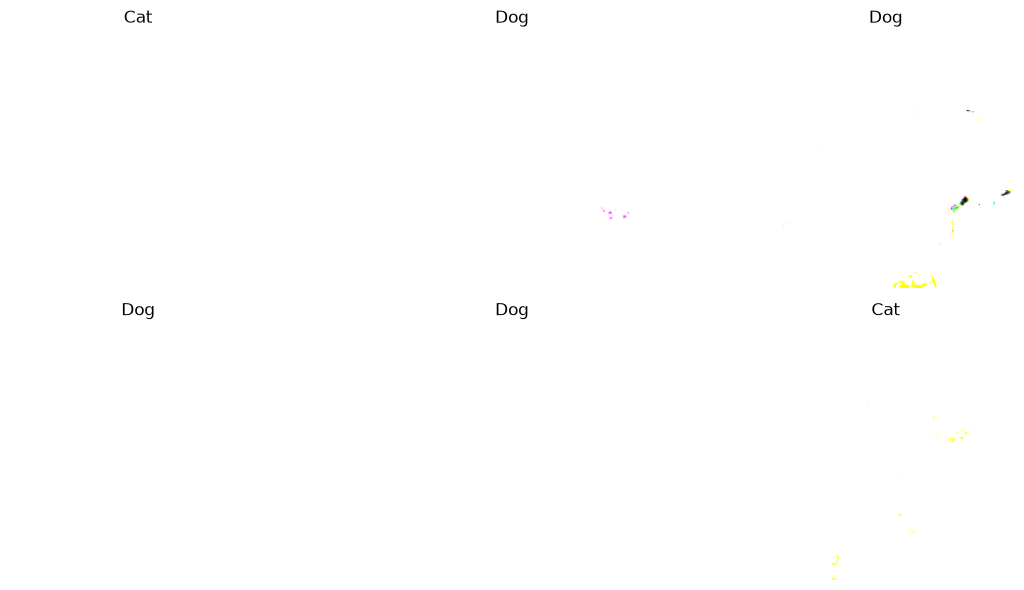

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

## Summary

The dataset is now prepared for training with reusable utilities stored in the source package. The next notebook can build and train the classification model from these datasets.